# Credit Card Fraud Detection

## Business Problem

Financial institutions need to identify potentially fraudulent transactions while minimizing the number of legitimate transactions incorrectly flagged for investigation.

This project analyzes credit card transactions to:

1. Understand the characteristics of fraudulent transactions.
2. Identify transaction-level patterns associated with fraud.
3. Investigate whether transaction timing and transaction value are associated with higher fraud risk.
4. Use SQL to answer targeted business questions.
5. Apply Isolation Forest to identify anomalous transactions.
6. Evaluate how well detected anomalies align with known fraudulent transactions.
7. Translate analytical findings into practical fraud-monitoring recommendations.

## Analytical Approach

The analysis combines:

- **Python** for data preparation, exploratory analysis and anomaly detection.
- **SQL / SQLite** for targeted transaction analysis.
- **Statistical analysis** to compare fraudulent and legitimate transactions.
- **Isolation Forest** for unsupervised anomaly detection.

In [1]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

## 1. Data Loading

The dataset contains 284,807 credit card transactions made over approximately two days.

The available variables include:

- `Time`: seconds elapsed since the first transaction.
- `V1`–`V28`: anonymized transaction features.
- `Amount`: transaction amount.
- `Class`: target variable where 0 represents legitimate transactions and 1 represents fraud.

In [2]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (284807, 31)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 2. Data Quality Assessment

Before analyzing fraud patterns, the dataset is checked for:

- Missing values
- Duplicate observations
- Data types
- Class distribution

This ensures that the subsequent analysis is based on a reliable analytical dataset.

In [5]:
missing_values = df.isnull().sum()
print(f"Missing values per column:\n{missing_values}")

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:
duplicate_count=df.duplicated().sum()
print(f"Duplicate rows:{duplicate_count}")

Duplicate rows:1081


In [7]:
df = df.drop_duplicates().copy()

print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (283726, 31)


In [8]:
print(f"Remaining duplicate rows: {df.duplicated().sum()}")

Remaining duplicate rows: 0


### Duplicate Records

The dataset was checked for exact duplicate observations. Duplicate rows were identified where all transaction fields, including the fraud label, were identical.

These exact duplicates were removed to prevent repeated observations from disproportionately influencing transaction counts, fraud-rate calculations and anomaly detection.

After removal, the dataset was rechecked to confirm that no exact duplicate rows remained.

In [9]:
print(f"Duplicate rows found: {duplicate_count}")
print(f"Dataset shape after removing duplicates: {df.shape}")
print(f"Remaining duplicate rows: {df.duplicated().sum()}")

Duplicate rows found: 1081
Dataset shape after removing duplicates: (283726, 31)
Remaining duplicate rows: 0


In [10]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [11]:
class_counts = df["Class"].value_counts()

class_counts

Class
0    283253
1       473
Name: count, dtype: int64

In [12]:
class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

class_percentages

Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64

In [13]:
fraud_rate = df["Class"].mean()

print(f"Fraud rate: {fraud_rate:.4%}")

Fraud rate: 0.1667%


In [14]:
fraud_summary = pd.DataFrame({
    "Transaction_Count": class_counts,
    "Percentage": class_percentages
})

fraud_summary.index = ["Legitimate", "Fraud"]

fraud_summary

,Transaction_Count,Percentage
Legitimate,283253,99.8333
Fraud,473,0.1667


### Class Distribution

The dataset is highly imbalanced, with Fraudulent transactions representing only 0.1667% of the cleaned dataset, while 99.8333% are legitimate transactions.

This imbalance is important for fraud detection because a model can achieve very high accuracy simply by classifying most transactions as legitimate.

Therefore, model performance will be evaluated primarily using:

- Precision
- Recall
- F1-score

rather than accuracy alone.

In [15]:
SECONDS_PER_DAY = 24 * 60 * 60

df["Time_of_Day_Seconds"] = df["Time"] % SECONDS_PER_DAY

df["Hour"] = (
    df["Time_of_Day_Seconds"] // 3600
).astype(int)

df[["Time", "Time_of_Day_Seconds", "Hour"]].head()

,Time,Time_of_Day_Seconds,Hour
0,0.0,0.0,0
1,0.0,0.0,0
2,1.0,1.0,0
3,1.0,1.0,0
4,2.0,2.0,0


In [16]:
df["Is_Early_Morning"] = (
    df["Hour"].between(0, 5)
).astype(int)

df[["Hour", "Is_Early_Morning"]].head()

,Hour,Is_Early_Morning
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [17]:
df["Log_Amount"] = np.log1p(df["Amount"])

df[["Amount", "Log_Amount"]].head()

,Amount,Log_Amount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


## 3. Feature Engineering

Three transaction-level features are created:

- **Time_of_Day_Seconds:** converts the elapsed transaction time into its position within a 24-hour cycle.
- **Hour:** extracts the approximate hour of the day.
- **Is_Early_Morning:** identifies transactions occurring between 00:00 and 05:59.
- **Log_Amount:** log-transforms transaction amount to reduce the influence of extreme values.

These features allow the analysis to investigate transaction timing and transaction value more directly.

In [18]:
df[[
    "Time",
    "Time_of_Day_Seconds",
    "Hour",
    "Is_Early_Morning",
    "Amount",
    "Log_Amount",
    "Class"
]].head(10)

,Time,Time_of_Day_Seconds,Hour,Is_Early_Morning,Amount,Log_Amount,Class
0,0.0,0.0,0,1,149.62,5.014760,0
1,0.0,0.0,0,1,2.69,1.305626,0
2,1.0,1.0,0,1,378.66,5.939276,0
3,1.0,1.0,0,1,123.50,4.824306,0
4,2.0,2.0,0,1,69.99,4.262539,0
5,2.0,2.0,0,1,3.67,1.541159,0
6,4.0,4.0,0,1,4.99,1.790091,0
7,7.0,7.0,0,1,40.80,3.732896,0
8,7.0,7.0,0,1,93.20,4.545420,0
9,9.0,9.0,0,1,3.68,1.543298,0


In [19]:
df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
Class,,,,
0,283253,88.413575,22.00,25691.16
1,473,123.871860,9.82,2125.87


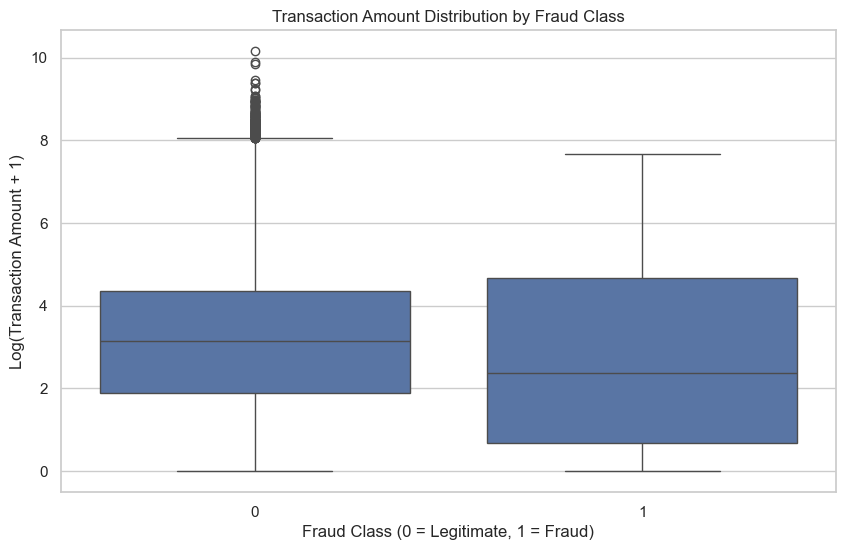

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Log_Amount"
)

plt.title("Transaction Amount Distribution by Fraud Class")
plt.xlabel("Fraud Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Log(Transaction Amount + 1)")

plt.show()

In [21]:
amount_99th_percentile = df["Amount"].quantile(0.99)

print(
    f"99th percentile transaction amount: "
    f"${amount_99th_percentile:,.2f}"
)

99th percentile transaction amount: $1,018.97


In [22]:
df["High_Value"] = (
    df["Amount"] >= amount_99th_percentile
).astype(int)

In [23]:
fraud_rate_by_value = (
    df.groupby("High_Value")["Class"]
    .agg(["count", "sum", "mean"])
)

fraud_rate_by_value

,count,sum,mean
High_Value,,,
0,280888,464,0.001652
1,2838,9,0.003171


In [24]:
fraud_rate_by_value.columns = [
    "Transactions",
    "Fraud_Count",
    "Fraud_Rate"
]

fraud_rate_by_value["Fraud_Rate"] *= 100

fraud_rate_by_value

,Transactions,Fraud_Count,Fraud_Rate
High_Value,,,
0,280888,464,0.165190
1,2838,9,0.317125


In [25]:
fraud_rate_by_hour = (
    df.groupby("Hour")["Class"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

fraud_rate_by_hour["Fraud_Rate"] *= 100

fraud_rate_by_hour

,Transactions,Fraud_Count,Fraud_Rate
Hour,,,
0,7647,6,0.078462
1,4208,10,0.237643
2,3308,48,1.451028
3,3487,17,0.487525
4,2204,23,1.043557
5,2988,11,0.368139
6,4082,9,0.220480
7,7233,23,0.317987
8,10232,9,0.087959


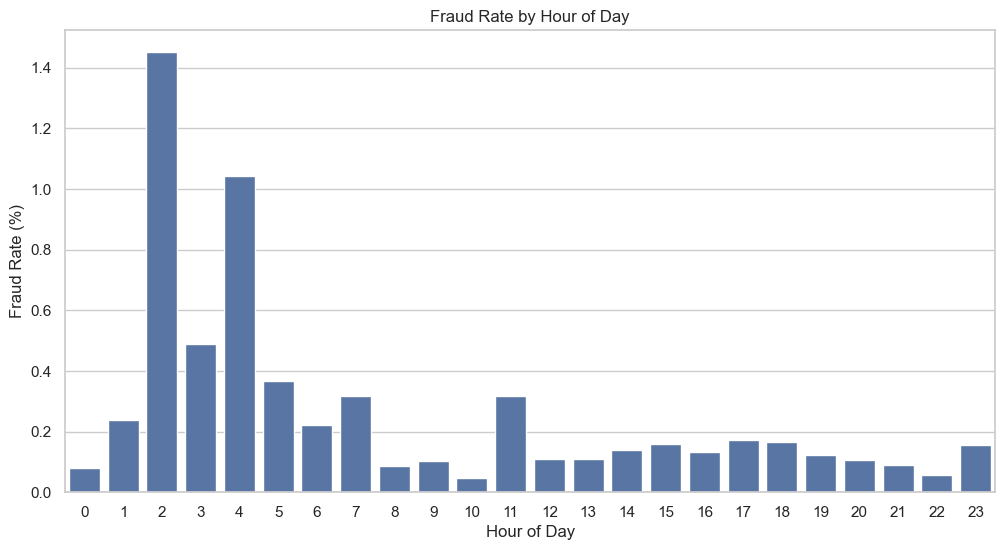

In [26]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=fraud_rate_by_hour.reset_index(),
    x="Hour",
    y="Fraud_Rate"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [27]:
early_morning_analysis = (
    df.groupby("Is_Early_Morning")["Class"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

early_morning_analysis["Fraud_Rate"] *= 100

early_morning_analysis

,Transactions,Fraud_Count,Fraud_Rate
Is_Early_Morning,,,
0,259884,358,0.137754
1,23842,115,0.482342


In [28]:
early_rate = early_morning_analysis.loc[1, "Fraud_Rate"]
other_rate = early_morning_analysis.loc[0, "Fraud_Rate"]

relative_risk = early_rate / other_rate

print(f"Early-morning fraud rate: {early_rate:.4f}%")
print(f"Other-hours fraud rate: {other_rate:.4f}%")
print(f"Relative risk: {relative_risk:.2f}x")

Early-morning fraud rate: 0.4823%
Other-hours fraud rate: 0.1378%
Relative risk: 3.50x


### Early-Morning Fraud Pattern

Transactions occurring between 00:00 and 05:59 show a higher observed fraud rate than transactions occurring during other hours.

- Early-morning transactions: **0.4823% fraud rate**
- Other transactions: **0.1378% fraud rate**

The early-morning fraud rate is approximately **3.5 times higher** than the rate observed during other hours.

This suggests that transaction timing may be a useful risk indicator for fraud monitoring. However, time of day should not be treated as a standalone fraud rule because most early-morning transactions are still legitimate.

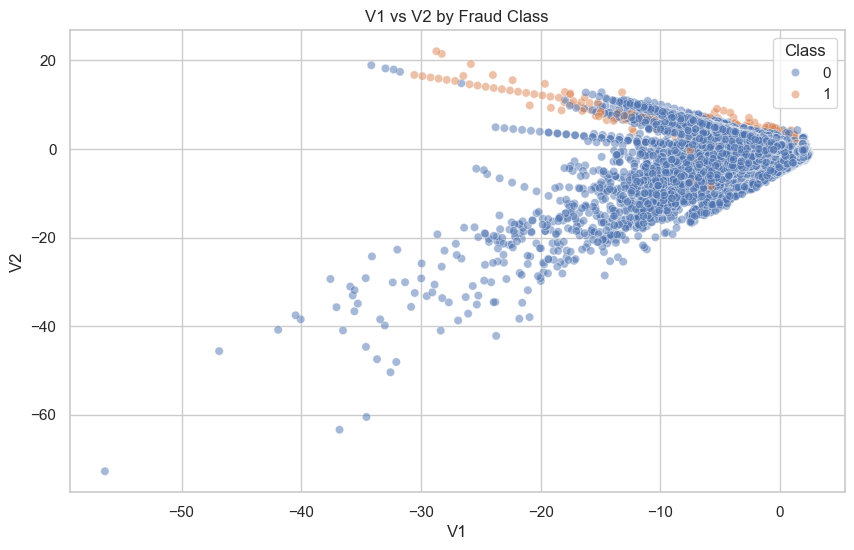

In [29]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="V1",
    y="V2",
    hue="Class",
    alpha=0.5
)

plt.title("V1 vs V2 by Fraud Class")
plt.xlabel("V1")
plt.ylabel("V2")

plt.show()

## SQL Analysis

### Question 1
Are high-value transactions disproportionately associated with fraud?

### Question 2
Are transactions occurring during early-morning hours associated with higher fraud rates?

### Question 3
Are there periods with unusually high transaction volumes?

In [30]:
# Creating a temporary in-memory SQLite database and loading the DataFrame into it for SQL queries.
conn = sqlite3.connect(":memory:")

df.to_sql(
    "transactions",
    conn,
    index=False,
    if_exists="replace"
)

283726

In [31]:
#Checking the database connection and the data in the transactions table
select_query = "SELECT * FROM transactions LIMIT 5;"
select_result = pd.read_sql_query(select_query, conn)
select_result

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Time_of_Day_Seconds,Hour,Is_Early_Morning,Log_Amount,High_Value
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0,1,5.014760,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,0,1,1.305626,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.0,0,1,5.939276,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,1.0,0,1,4.824306,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,2.0,0,1,4.262539,0


In [32]:
# Query for total transactions, fraud count and fraud rate using SQL
query = """
SELECT 
    COUNT(*) AS Transactions,
    SUM(Class) AS Fraud_Count,
    AVG(Class) * 100 AS Fraud_Rate
FROM transactions;
"""

result = pd.read_sql_query(query, conn)

result

,Transactions,Fraud_Count,Fraud_Rate
0,283726,473,0.16671


### Question 1
**Are high-value transactions disproportionately associated with fraud?**

To investigate this, I define high-value transactions as the top 1%
of transactions ranked by transaction amount.

In [33]:
query_q1 = """
WITH ranked_transactions AS (
    SELECT
        Amount,
        Class,
        NTILE(100) OVER (ORDER BY Amount DESC) AS amount_percentile
    FROM transactions
)

SELECT
    CASE
        WHEN amount_percentile = 1 THEN 'Top 1% by Amount'
        ELSE 'Other 99%'
    END AS Transaction_Group,
    COUNT(*) AS Transactions,
    SUM(Class) AS Fraud_Count,
    AVG(Class) * 100 AS Fraud_Rate,
    AVG(Amount) AS Average_Amount
FROM ranked_transactions
GROUP BY Transaction_Group;
"""

q1_result = pd.read_sql_query(query_q1, conn)

q1_result

,Transaction_Group,Transactions,Fraud_Count,Fraud_Rate,Average_Amount
0,Other 99%,280888,464,0.165190,70.819139
1,Top 1% by Amount,2838,9,0.317125,1835.713647


In [39]:
fraud_rate_ratio = (
    q1_result.loc[
        q1_result["Transaction_Group"] == "Top 1% by Amount",
        "Fraud_Rate"
    ].iloc[0]
    /
    q1_result.loc[
        q1_result["Transaction_Group"] == "Other 99%",
        "Fraud_Rate"
    ].iloc[0]
)

print(f"High-value transactions have a {fraud_rate_ratio:.2f}x higher fraud rate.")

High-value transactions have a 1.92x higher fraud rate.


### Interpretation

The analysis investigates whether high-value transactions are disproportionately associated with fraud. High-value transactions are defined as the top 1% of transactions ranked by transaction amount.

The results show that the **Top 1% by Amount** have a fraud rate of **0.317%**, compared with **0.165%** for the remaining 99% of transactions. This means that the fraud rate among high-value transactions is approximately **1.9 times higher** than among other transactions.

Although the Top 1% contain only **9 fraudulent transactions**, compared with **464 fraudulent transactions** in the remaining 99%, this difference in fraud count is largely driven by the much smaller number of transactions in the Top 1% (2,838 compared with 280,888). Therefore, **fraud rate is a more appropriate metric for comparing the two groups than the absolute fraud count**.

The average transaction amount also shows a substantial difference between the groups. Transactions in the Top 1% have an average amount of approximately **1,835.71**, compared with **70.82** for the remaining 99%. This confirms that the segmentation successfully isolates substantially higher-value transactions.

### Business Insight

The results provide evidence that **high-value transactions are disproportionately associated with fraud**. The approximately **1.9× higher fraud rate** suggests that transaction amount may be a useful indicator of fraud risk.

From a fraud-management perspective, high-value transactions could therefore be considered for **additional monitoring or risk-based controls**. However, transaction amount should not be used as a standalone fraud indicator. Despite their higher relative fraud rate, the Top 1% account for only **9 of the 473 fraudulent transactions** observed in these two groups. The majority of fraud therefore occurs outside the highest-value transactions.

### Conclusion

**High-value transactions show a higher relative fraud risk, but they do not account for the majority of fraud.** Transaction amount may therefore be useful as one component of a broader fraud-risk detection strategy, alongside other transaction and customer-level indicators.

,Time_Group,Transactions,Fraud_Count,Fraud_Rate
0,Early Morning,23842,115,0.482342
1,Other Hours,259884,358,0.137754


### Question 2

**Are transactions occurring during early-morning hours associated with higher fraud rates?**

To investigate this, I use the transaction `Time` variable to identify the hour in which each transaction occurred. The hour is represented on a 24-hour scale, where 0 represents midnight, 1 represents 1:00 AM and so forth.

I define **early-morning hours as 00:00–05:59 (hours 0–5)** and classify all transactions into two groups:

- **Early Morning:** hours 0–5
- **Other Hours:** hours 6–23

I then compare the number of transactions, fraud count and fraud rate between the two groups. Fraud rate is calculated as the percentage of transactions classified as fraudulent within each time group.

In [45]:
# Query for hourly transactions, fraud count and fraud rate using SQL
query_q2_hourly = """
SELECT
    CAST(strftime('%H', time, 'unixepoch') AS INTEGER) AS Hour,
    COUNT(*) AS Transactions,
    SUM(Class) AS Fraud_Count,
    AVG(Class) * 100 AS Fraud_Rate
FROM transactions
GROUP BY Hour
ORDER BY Hour;
"""

q2_hourly = pd.read_sql_query(query_q2_hourly, conn)

q2_hourly

,Hour,Transactions,Fraud_Count,Fraud_Rate
0,0,7647,6,0.078462
1,1,4208,10,0.237643
2,2,3308,48,1.451028
3,3,3487,17,0.487525
4,4,2204,23,1.043557
5,5,2988,11,0.368139
6,6,4082,9,0.220480
7,7,7233,23,0.317987
8,8,10232,9,0.087959
9,9,15767,16,0.101478


In [46]:
# Query for early-morning transactions, fraud count and fraud rate using SQL
query_q2 = """
SELECT
    CASE
        WHEN CAST(strftime('%H', time, 'unixepoch') AS INTEGER)
             BETWEEN 0 AND 5
        THEN 'Early Morning'
        ELSE 'Other Hours'
    END AS Time_Group,
    
    COUNT(*) AS Transactions,
    SUM(Class) AS Fraud_Count,
    AVG(Class) * 100 AS Fraud_Rate

FROM transactions

GROUP BY Time_Group;
"""

q2_result = pd.read_sql_query(query_q2, conn)

q2_result

,Time_Group,Transactions,Fraud_Count,Fraud_Rate
0,Early Morning,23842,115,0.482342
1,Other Hours,259884,358,0.137754


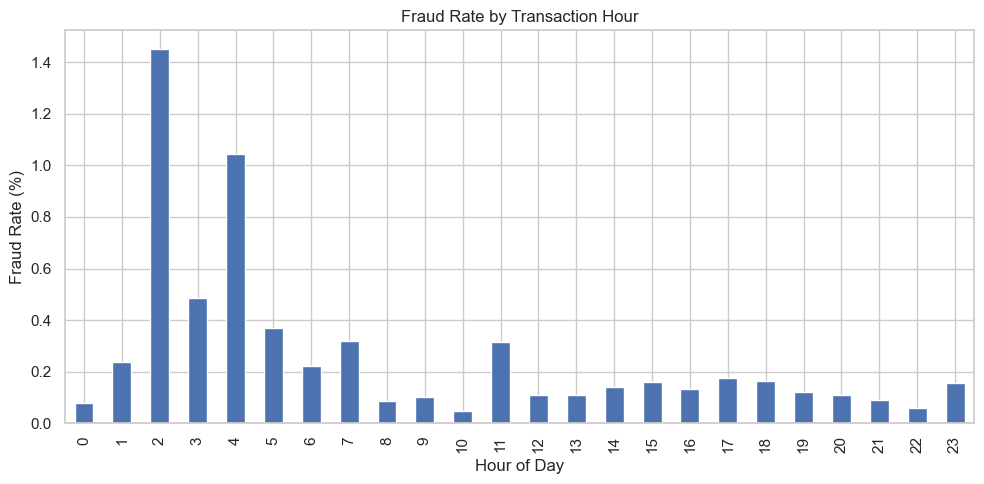

In [48]:
ax = q2_hourly.plot(
    x="Hour",
    y="Fraud_Rate",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

ax.set_title("Fraud Rate by Transaction Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Fraud Rate (%)")

plt.tight_layout()

plt.savefig(
    "Visualizations/fraud_rate_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

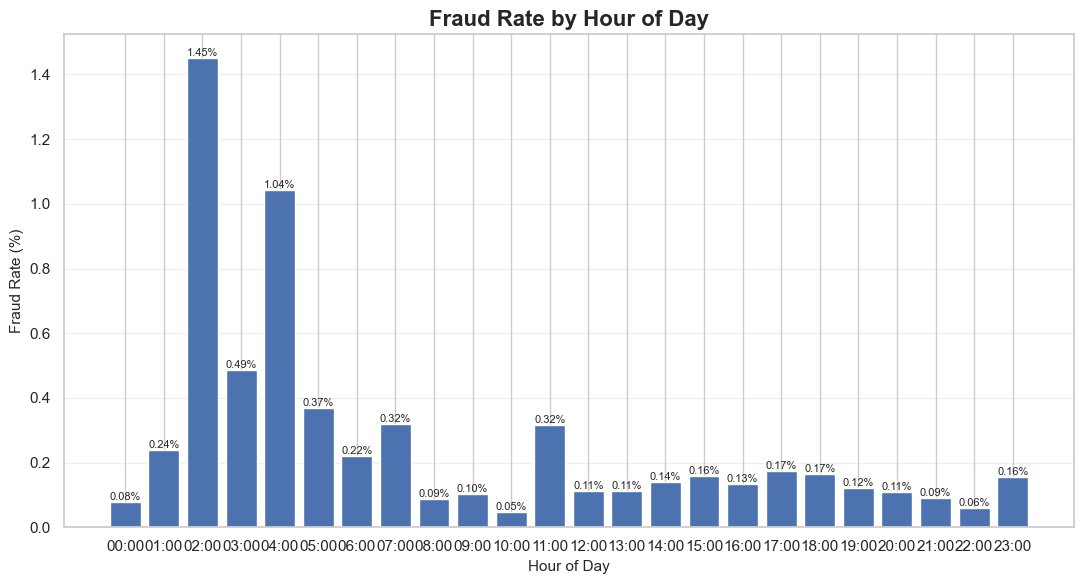

In [49]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    q2_hourly["Hour"],
    q2_hourly["Fraud_Rate"]
)

ax.set_title(
    "Fraud Rate by Hour of Day",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Hour of Day", fontsize=11)
ax.set_ylabel("Fraud Rate (%)", fontsize=11)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{hour:02d}:00" for hour in range(24)])

ax.grid(
    axis="y",
    alpha=0.3
)

# Add fraud-rate values above each bar
for bar, rate in zip(bars, q2_hourly["Fraud_Rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "Visualizations/fraud_rate_by_hour_stakeholders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

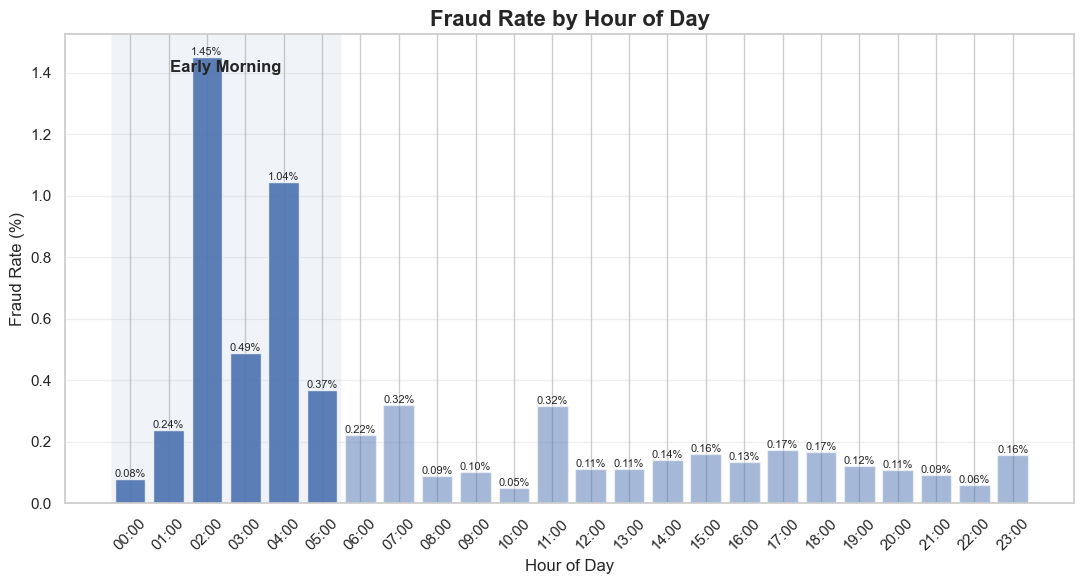

In [51]:
fig, ax = plt.subplots(figsize=(11, 6))

# Create bars
bars = ax.bar(
    q2_hourly["Hour"],
    q2_hourly["Fraud_Rate"]
)

# Highlight early-morning hours
for i, bar in enumerate(bars):
    if q2_hourly.loc[i, "Hour"] <= 5:
        bar.set_alpha(0.9)
    else:
        bar.set_alpha(0.5)

ax.set_title(
    "Fraud Rate by Hour of Day",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Fraud Rate (%)")

ax.set_xticks(range(24))
ax.set_xticklabels(
    [f"{hour:02d}:00" for hour in range(24)],
    rotation=45
)

ax.grid(
    axis="y",
    alpha=0.3
)

# Add values
for bar, rate in zip(bars, q2_hourly["Fraud_Rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Highlight the early-morning region
ax.axvspan(
    -0.5,
    5.5,
    alpha=0.08
)

ax.text(
    2.5,
    ax.get_ylim()[1] * 0.92,
    "Early Morning",
    ha="center",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Visualizations/fraud_rate_by_hour_early_morning_highlighted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

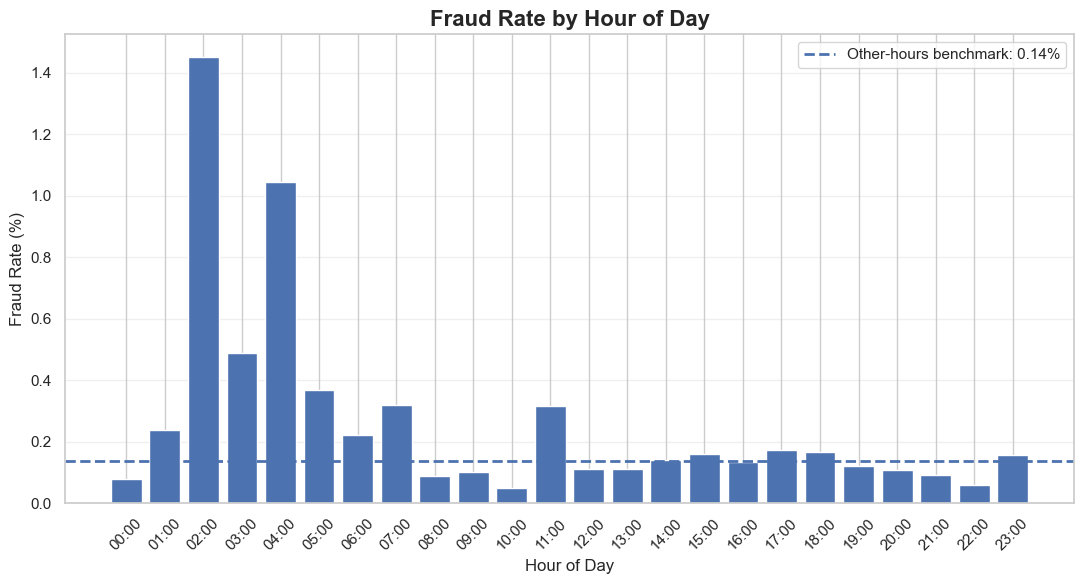

In [52]:
other_hours_rate = (
    q2_result.loc[
        q2_result["Time_Group"] == "Other Hours",
        "Fraud_Rate"
    ].iloc[0]
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    q2_hourly["Hour"],
    q2_hourly["Fraud_Rate"]
)

ax.axhline(
    other_hours_rate,
    linestyle="--",
    linewidth=2,
    label=f"Other-hours benchmark: {other_hours_rate:.2f}%"
)

ax.set_title(
    "Fraud Rate by Hour of Day",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Fraud Rate (%)")

ax.set_xticks(range(24))
ax.set_xticklabels(
    [f"{hour:02d}:00" for hour in range(24)],
    rotation=45
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "Visualizations/fraud_rate_by_hour_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The results show a substantial difference in fraud rates between early-morning transactions and transactions occurring during other hours.

Early-morning transactions have a fraud rate of **0.482%**, compared with **0.138%** for transactions occurring during other hours. This means that the fraud rate during the early morning is approximately **3.5 times higher** than during other hours.

There are **115 fraudulent transactions among 23,842 early-morning transactions**, compared with **358 fraudulent transactions among 259,884 transactions during other hours**.

Although the absolute number of fraudulent transactions is higher during other hours, this is largely because the majority of transactions occur during those hours. The fraud rate provides a more appropriate comparison because it accounts for the different number of transactions in each group.

### Business Insight

The results provide evidence that **early-morning transactions are disproportionately associated with fraud**. The approximately **3.5× higher fraud rate** suggests that time of day may be a useful indicator of fraud risk.

From a fraud-detection perspective, transactions occurring during early-morning hours could therefore be considered for **additional monitoring or risk-based controls**, particularly when combined with other risk indicators.

However, time of day should not be treated as a standalone fraud indicator. Most fraudulent transactions in this dataset still occur during other hours, so using early-morning activity alone would miss a substantial proportion of fraud.

### Conclusion

**Early-morning transactions have a substantially higher fraud rate than transactions occurring during other hours, with a fraud rate approximately 3.5 times higher. This suggests that transaction time may be a useful feature for identifying potentially higher-risk transactions.**

### Question 3

**Are there periods with unusually high transaction volumes?**

To investigate this, I aggregate transactions into consecutive one-hour blocks based on the `Time` variable. For each hourly block, I calculate the total number of transactions, fraud count and fraud rate.

I then calculate the **mean** and **standard deviation** of hourly transaction volume across all hourly blocks. I classified the busiest 5% of hourly periods as unusually high transaction activity.

Finally, I classify each hourly block as either **Normal** or **Unusually High** based on this threshold.

This approach identifies periods where transaction activity is substantially higher than the typical hourly level.

In [53]:
query_q3 = """
WITH hourly_activity AS (
    SELECT
        CAST(time / 3600 AS INTEGER) AS Hour_Block,
        COUNT(*) AS Transaction_Count,
        SUM(Class) AS Fraud_Count,
        AVG(Class) * 100 AS Fraud_Rate
    FROM transactions
    GROUP BY Hour_Block
)

SELECT
    Hour_Block,
    Transaction_Count,
    Fraud_Count,
    Fraud_Rate
FROM hourly_activity
ORDER BY Transaction_Count DESC;
"""

q3_result = pd.read_sql_query(query_q3, conn)

q3_result.head(10)

,Hour_Block,Transaction_Count,Fraud_Count,Fraud_Rate
0,21,9875,14,0.141772
1,20,8946,8,0.089425
2,22,8943,3,0.033546
3,40,8626,8,0.092743
4,39,8567,12,0.140072
5,18,8548,10,0.116986
6,38,8508,10,0.117536
7,11,8474,43,0.507435
8,42,8411,18,0.214005
9,35,8307,10,0.120380


In [60]:
query_q3 = """
SELECT
    CAST(time / 3600 AS INTEGER) AS Hour_Block,
    COUNT(*) AS Transaction_Count,
    SUM(Class) AS Fraud_Count,
    AVG(Class) * 100 AS Fraud_Rate
FROM transactions
GROUP BY Hour_Block
ORDER BY Transaction_Count DESC;
"""

q3_result = pd.read_sql_query(query_q3, conn)

# Step 2: Calculate the average and standard deviation
# of hourly transaction volume in Python

mean_transactions = q3_result["Transaction_Count"].mean()
std_transactions = q3_result["Transaction_Count"].std()
q3_threshold_95 = q3_result["Transaction_Count"].quantile(0.95)

print(f"95th percentile threshold: {q3_threshold_95:.2f}")


# Step 3: Classify each hourly period

q3_result["Activity_Level_95"] = np.where(
    q3_result["Transaction_Count"] > q3_threshold_95,
    "Unusually High",
    "Normal"
)

# Step 5: Add the statistical benchmarks to the results

q3_result["Mean_Transactions"] = mean_transactions
q3_result["Std_Transactions"] = std_transactions
q3_result["Threshold"] = q3_threshold_95 


# Step 6: Display the periods with the highest activity

unusual_periods_95 = q3_result[
    q3_result["Activity_Level_95"] == "Unusually High"
].sort_values(
    "Transaction_Count",
    ascending=False
)

unusual_periods_95



95th percentile threshold: 8832.05


,Hour_Block,Transaction_Count,Fraud_Count,Fraud_Rate,Activity_Level_95,Mean_Transactions,Std_Transactions,Threshold
0,21,9875,14,0.141772,Unusually High,5910.958333,2860.0319,8832.05
1,20,8946,8,0.089425,Unusually High,5910.958333,2860.0319,8832.05
2,22,8943,3,0.033546,Unusually High,5910.958333,2860.0319,8832.05


### Threshold Selection

Rather than relying solely on a mean + 2 standard deviation threshold, I use the **95th percentile of hourly transaction volume** to identify unusually high activity.

This approach is appropriate because it does not require transaction volume to follow a normal distribution and provides an intuitive business interpretation: the highest 5% of hourly periods are considered unusually active.

A percentile-based threshold is also less sensitive to extreme observations than a mean-based threshold, making it useful for identifying unusually high transaction activity in potentially skewed transaction-volume data.

Therefore, an hourly period is classified as **Unusually High** when its transaction volume exceeds the 95th percentile of observed hourly transaction volume.

In [61]:
activity_summary = (
    q3_result
    .groupby("Activity_Level_95")
    .agg(
        Periods=("Hour_Block", "count"),
        Total_Transactions=("Transaction_Count", "sum"),
        Total_Fraud=("Fraud_Count", "sum"),
        Average_Fraud_Rate=("Fraud_Rate", "mean")
    )
    .reset_index()
)

activity_summary

,Activity_Level_95,Periods,Total_Transactions,Total_Fraud,Average_Fraud_Rate
0,Normal,45,255962,448,0.271593
1,Unusually High,3,27764,25,0.088248


### Interpretation

To identify unusually high transaction activity, I defined the **95th percentile of hourly transaction volume** as the threshold. This produced a threshold of **8,832 transactions per one-hour period**, meaning that hourly periods with more than 8,832 transactions were classified as unusually high.

Using this definition, **3 out of 48 hourly periods** were classified as unusually high:

- Hour Block 21: **9,875 transactions**
- Hour Block 20: **8,946 transactions**
- Hour Block 22: **8,943 transactions**

Together, these unusually high-activity periods accounted for **27,764 transactions** and **25 fraudulent transactions**.

### Fraud Comparison

Interestingly, the unusually high transaction-volume periods did **not** have higher fraud rates than normal periods.

The average fraud rate during normal periods was **0.272%**, compared with only **0.088%** during unusually high-activity periods.

This means that the average fraud rate during unusually high-activity periods was approximately **68% lower** than during normal periods:

**0.088% / 0.272% ≈ 0.32**

Therefore, although these periods experienced substantially higher transaction volumes, the elevated activity was **not accompanied by an elevated fraud rate** in this dataset.

### Business Insight

The analysis suggests that **high transaction volume alone is not a strong indicator of increased fraud risk**. The busiest periods generated more transactions, but their fraud rate was lower than that of normal periods.

This is an important finding from a fraud-management perspective. A fraud monitoring system that automatically treats transaction-volume spikes as evidence of increased fraud risk could generate unnecessary alerts or investigations.

Instead, transaction-volume anomalies should be considered alongside other fraud indicators, such as transaction amount, time of day, customer behavior, transaction frequency, and other relevant risk features.

### Conclusion

**There are periods of unusually high transaction activity, but these periods are not associated with higher fraud rates.** Using the 95th percentile as the activity threshold identified 3 unusually high-volume periods, with an average fraud rate of **0.088%**, compared with **0.272%** during normal periods.

Therefore, the results do **not** support the hypothesis that unusually high transaction volume is associated with increased fraud in this dataset. Transaction volume may still be useful for monitoring operational activity, but it should not be treated as a standalone indicator of fraud risk.